In [38]:
# import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path
sns.set_theme()

In [39]:
LOAD_PATH = Path("../data/data.parquet")
data = pd.read_parquet(LOAD_PATH)
print(data.shape)

data.head()

(8120, 31)


,value,coordinates,period.label,period.interval,period.datetime_from.utc,period.datetime_from.local,period.datetime_to.utc,period.datetime_to.local,parameter.id,parameter.name,...,coverage.expected_count,coverage.expected_interval,coverage.observed_count,coverage.observed_interval,coverage.percent_complete,coverage.percent_coverage,coverage.datetime_from.utc,coverage.datetime_from.local,coverage.datetime_to.utc,coverage.datetime_to.local
0,22.9,None,1hour,01:00:00,2026-01-05T07:00:00Z,2026-01-05T08:00:00+01:00,2026-01-05T08:00:00Z,2026-01-05T09:00:00+01:00,19,pm1,...,1,01:00:00,1,01:00:00,100.0,100.0,2026-01-05T07:00:00Z,2026-01-05T08:00:00+01:00,2026-01-05T08:00:00Z,2026-01-05T09:00:00+01:00
1,26.4,None,1hour,01:00:00,2026-01-05T08:00:00Z,2026-01-05T09:00:00+01:00,2026-01-05T09:00:00Z,2026-01-05T10:00:00+01:00,19,pm1,...,1,01:00:00,1,01:00:00,100.0,100.0,2026-01-05T08:00:00Z,2026-01-05T09:00:00+01:00,2026-01-05T09:00:00Z,2026-01-05T10:00:00+01:00
2,21.9,None,1hour,01:00:00,2026-01-05T09:00:00Z,2026-01-05T10:00:00+01:00,2026-01-05T10:00:00Z,2026-01-05T11:00:00+01:00,19,pm1,...,1,01:00:00,1,01:00:00,100.0,100.0,2026-01-05T09:00:00Z,2026-01-05T10:00:00+01:00,2026-01-05T10:00:00Z,2026-01-05T11:00:00+01:00
3,23.0,None,1hour,01:00:00,2026-01-05T10:00:00Z,2026-01-05T11:00:00+01:00,2026-01-05T11:00:00Z,2026-01-05T12:00:00+01:00,19,pm1,...,1,01:00:00,1,01:00:00,100.0,100.0,2026-01-05T10:00:00Z,2026-01-05T11:00:00+01:00,2026-01-05T11:00:00Z,2026-01-05T12:00:00+01:00
4,19.1,None,1hour,01:00:00,2026-01-05T11:00:00Z,2026-01-05T12:00:00+01:00,2026-01-05T12:00:00Z,2026-01-05T13:00:00+01:00,19,pm1,...,1,01:00:00,1,01:00:00,100.0,100.0,2026-01-05T11:00:00Z,2026-01-05T12:00:00+01:00,2026-01-05T12:00:00Z,2026-01-05T13:00:00+01:00


In [40]:
data.columns

Index(['value', 'coordinates', 'period.label', 'period.interval',
       'period.datetime_from.utc', 'period.datetime_from.local',
       'period.datetime_to.utc', 'period.datetime_to.local', 'parameter.id',
       'parameter.name', 'parameter.units', 'parameter.display_name',
       'summary.min', 'summary.q02', 'summary.q25', 'summary.median',
       'summary.q75', 'summary.q98', 'summary.max', 'summary.sd',
       'summary.avg', 'coverage.expected_count', 'coverage.expected_interval',
       'coverage.observed_count', 'coverage.observed_interval',
       'coverage.percent_complete', 'coverage.percent_coverage',
       'coverage.datetime_from.utc', 'coverage.datetime_from.local',
       'coverage.datetime_to.utc', 'coverage.datetime_to.local'],
      dtype='object')

In [41]:
df = data.loc[:, [
    "value",
    "period.datetime_from.local",
    "parameter.name"
]]

In [42]:
df = df.rename(columns={
    "period.datetime_from.local": "timestamp",
    "parameter.name": "parameter"
})

In [43]:
df.head()

,value,timestamp,parameter
0,22.9,2026-01-05T08:00:00+01:00,pm1
1,26.4,2026-01-05T09:00:00+01:00,pm1
2,21.9,2026-01-05T10:00:00+01:00,pm1
3,23.0,2026-01-05T11:00:00+01:00,pm1
4,19.1,2026-01-05T12:00:00+01:00,pm1


In [44]:
df2 = df.pivot(
    columns="parameter",
    index="timestamp",
    values="value"
    ).reset_index().copy()

In [45]:
df2["timestamp"] = pd.to_datetime(df2["timestamp"])

<Axes: xlabel='parameter', ylabel='parameter'>

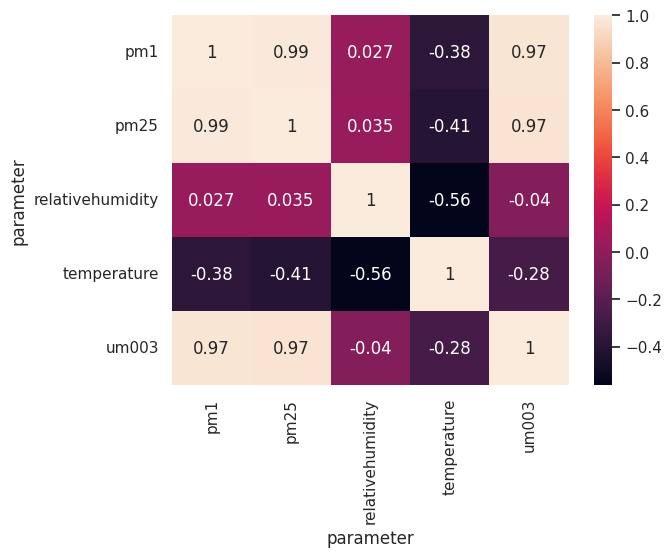

In [46]:
sns.heatmap(
    df2.drop("timestamp", axis=1).corr(),
    annot=True,
    )

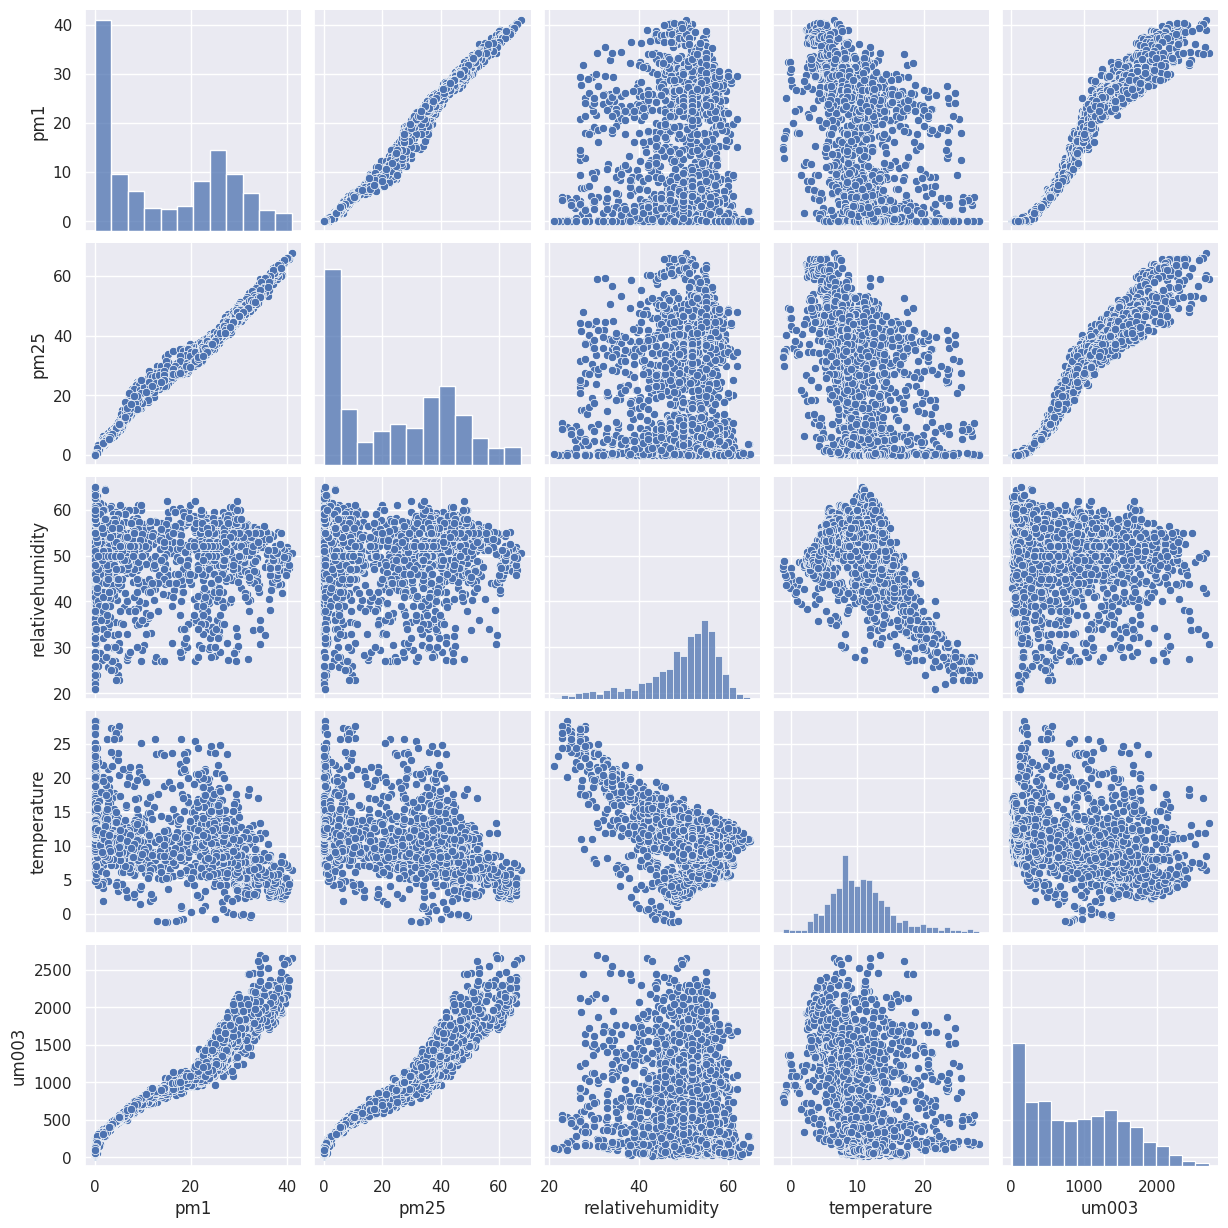

In [47]:
sns.pairplot(df2)

# Date features

In [48]:
def is_weekend(day_of_week: int) -> int:
    match day_of_week:
        case 0 | 7:
            return 1
        case _:
            return 0

In [49]:
def stringify_year_month(row) -> str:
    return f"{row['year']}-{row['month']}"

In [50]:
df2['year'] = df2['timestamp'].dt.year
df2['month'] = df2['timestamp'].dt.month
df2['day_of_week'] = df2['timestamp'].dt.day_of_week
df2['hour_of_day'] = df2['timestamp'].dt.hour
df2['is_weekend'] = df2['day_of_week'].apply(lambda x: is_weekend(x))
df2['year_month'] = df2['timestamp'].dt.strftime(date_format="%Y-%m")

# Rolling & lag

In [51]:
rolling_features = ['pm1', 'pm25']
lag_periods = [3, 6, 9, 12]
rolling_window = [12, 24]

In [52]:
for feature in rolling_features:
    for window in rolling_window:
        df2[f'rolling_{feature}_{str(window)}'] = df2[feature].rolling(window=window).mean()
    for periods in lag_periods:
        df2[f'lag_{feature}_{str(periods)}'] = df2[feature].shift(periods=periods)

In [61]:
df2.index.name = 'id'

In [76]:
df2_numeric_cols = df2.select_dtypes(['float64', 'int32'])

In [91]:
df_corrs = pd.DataFrame(df2_numeric_cols.corr()['pm1']).sort_values('pm1', ascending=False)
df_corrs

,pm1
parameter,
pm1,1.000000
pm25,0.993074
um003,0.972296
lag_pm1_3,0.902591
lag_pm25_3,0.901646
rolling_pm1_12,0.894031
rolling_pm25_12,0.888695
rolling_pm1_24,0.841731
rolling_pm25_24,0.836450
